In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load data
df = pd.read_csv("../data/processed/features_v2.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values("date")

# Train-test split (same as before)
split_date = df['date'].quantile(0.8)

train = df[df['date'] < split_date].copy()
test  = df[df['date'] >= split_date].copy()


In [8]:
target = "positionOrder"

drop_cols = [
    "raceId", "driverId", "constructorId",
    "date",
    "points",
    "avgLapTime_s",
    "positionOrder"
]

features = [col for col in df.columns if col not in drop_cols]

X_train = train[features]
X_test  = test[features]

y_train = train[target]
y_test  = test[target]


In [9]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MAE: 3.1972456726940224
R2: 0.47412930477506277


In [10]:
results_finish = test.copy()

results_finish["prediction"] = preds
results_finish["error"] = results_finish["positionOrder"] - results_finish["prediction"]
results_finish["abs_error"] = np.abs(results_finish["error"])


is_DNF
False    3.197246
Name: abs_error, dtype: float64


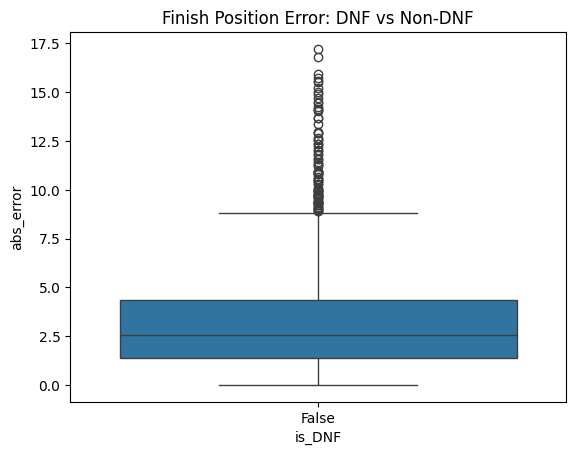

In [11]:
# Example definition (modify if you have better DNF flag)
results_finish["is_DNF"] = results_finish["positionOrder"] > 20


dnf_error = results_finish.groupby("is_DNF")["abs_error"].mean()
print(dnf_error)


sns.boxplot(x="is_DNF", y="abs_error", data=results_finish)
plt.title("Finish Position Error: DNF vs Non-DNF")
plt.show()


circuitId
20    4.960680
1     3.891993
80    3.861040
73    3.832582
3     3.701566
7     3.619454
18    3.610652
5     3.548712
69    3.401715
14    3.361306
Name: abs_error, dtype: float64


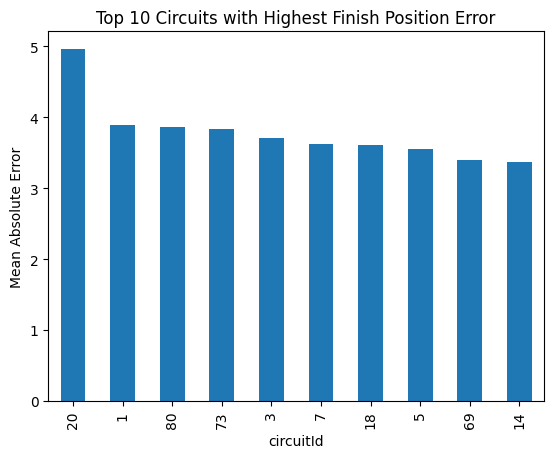

In [12]:
circuit_errors_finish = (
    results_finish
    .groupby("circuitId")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(circuit_errors_finish.head(10))


circuit_errors_finish.head(10).plot(kind="bar")
plt.title("Top 10 Circuits with Highest Finish Position Error")
plt.ylabel("Mean Absolute Error")
plt.show()


In [13]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


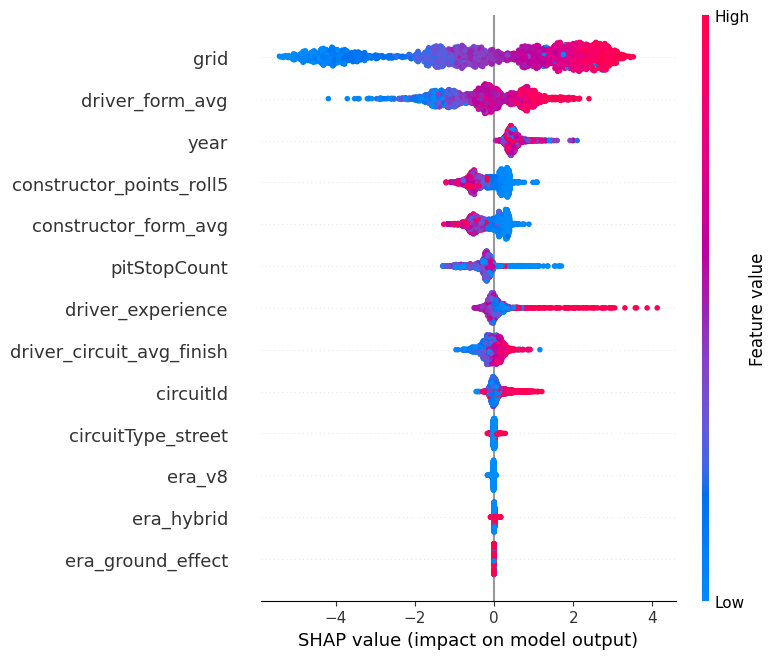

In [14]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)